# Introduction to BrainIAK tutorials


Congratulations, if you are viewing this Jupyter notebook, you have already acquired many of the skills necessary to excel in this course and you are well on your way to learning cutting-edge methods for cognitive neuroscience!

For users on NeuroLibre, you are seeing a ready to run version of these tutorials that needed no installation or configuration on your part. If you would like to install and use these tutorials on your own machines, follow the instructions on [brainiak tutorials](http://brainiak.org/tutorials).

In this course we will use a variety of tools, many of which will likely be new to you. Don't worry if you are having trouble wrapping your head around them now: by the end of this course you will be proficient in not only these useful skills but also the exciting analyses that use them. 

## Goal of this notebook
    1. Familiarize yourself with the tools that will be used in these notebooks. 


## Table of Contents

Exercises
>[Exercise 1](#ex1)  

[Contributions](#contributions)

## Resources <a id="resource"></a>

Here are some resources (Python, fMRI and machine learning, etc.): 
<a href="https://github.com/brainiak/tutorials/wiki/Resources">BrainIAK tutorials resource page</a>

## Import necessary packages

While importing packages, you may see warning messages. It is safe to ignore these warnings as they will not impact your execution of the tutorials. 

In [7]:
# suppress warnings
import warnings
import sys 
if not sys.warnoptions:
    warnings.simplefilter("ignore")

# The plotting tool we will be using in this course
import matplotlib.pyplot as plt

# Module essential for data organization and manipulation
import numpy as np #numpy's "nickname" is np

# Import a function from BrainIAK to simulate fMRI data
import brainiak.utils.fmrisim as sim  

# display the plots inline 
%matplotlib inline 
# autosave for every 5 secs
%autosave 5

Autosaving every 5 seconds


### Brain template 

We are now going to use some of the tools we just loaded. First we'll call a function from `brainiak` to load a gray matter mask from the MNI152 standard brain. Here's an article talking about different anatomical standards, including MNI152: [Structural Brain Atlases: Design, Rationale, and Applications in Normal and Pathological Cohorts](https://www.ncbi.nlm.nih.gov/pmc/articles/PMC4324755/)

In [8]:
# Set the size (in terms of X, Y, Z) of the volume we want to create
dimensions = np.asarray([64, 64, 64])

# Generate an anatomical image with the size above of brain voxels in gray matter
# This outputs variables for two versions of the image, binary (mask) and probabilistic (template)
mask, template = sim.mask_brain(dimensions, mask_self=False)

Congrats, you just ran a command from BrainIAK!!

We are now going to take a slice from that template and display it.

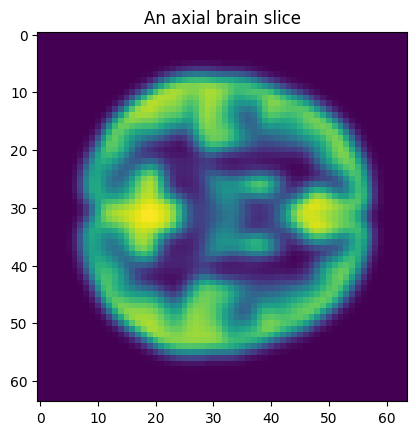

In [9]:
# Get an axial (a.k.a. transverse or horizontal) slice halfway through the brain
mid_idx = dimensions[2] // 2
axial_slice = template[:, :, mid_idx]

# imshow can visualize a 2d array 
plt.imshow(axial_slice)
plt.title('An axial brain slice');

There are great tools in Python for exploring brains in notebooks. One such tool is [niwidgets](http://nipy.org/niwidgets/examples.html). Below we use that tool to look at the brain interactively. If you cannot install it, there are other options to consider, like [nibabel.viewers.OrthoSlicer3D](https://nipy.org/nibabel/reference/nibabel.viewers.html#nibabel.viewers.OrthoSlicer3D)

In [10]:
try:
    # Load in the new variable
    from niwidgets import NiftiWidget

    template_nii = nib.Nifti1Image(template, np.eye(4))
    viewer = NiftiWidget(template_nii)
    viewer.nifti_plotter();

except:
    print('niwidgets cannot run, try installing it or some other viewing tool')

niwidgets cannot run, try installing it or some other viewing tool


### "help()"

`help` is a very useful function in Python. If you type `help(function_name)` in Python, you will get some basic infomation about how to use this function. If you run the following line, you will see that `sim.mask_brain` takes the dimension of x, y, and z, and then output a MNI152 template with the specified dimensions. Note, you can also do this by typing [SHIFT] + [TAB] while the cursor is hovering over a function name. 

**Note:** The [SHIFT] + [TAB] works in Jupyter environments, but you will see small differences in this functionality when these notebooks are are used in other environments such as NeuroLibre that use Binder.

In [11]:
help(sim.mask_brain)

Help on function mask_brain in module brainiak.utils.fmrisim:

mask_brain(volume, template_name=None, mask_threshold=None, mask_self=True)
    Mask the simulated volume
    This creates a mask specifying the approximate likelihood that a voxel is
    part of the brain. All values are bounded to the range of 0 to 1. An
    appropriate threshold to isolate brain voxels is >0.2. Critically,
    the data that should be used to create a template shouldn't already be
    masked/skull stripped. If it is then it will give in accurate estimates
    of non-brain noise and corrupt estimations of SNR.

    Parameters
    ----------

    volume : multidimensional array
        Either numpy array of a volume or a tuple describing the dimensions
        of the mask to be created

    template_name : str
        What is the path to the template to be loaded? If empty then it
        defaults to an MNI152 grey matter mask. This is ignored if mask_self
        is True.

    mask_threshold : float
      

### Look at the source code
If you want to see the source code, you can use the `getsource` function from the `inspect` package. 

Run the following code to see the source code of `sim.mask_brain`. 

In [12]:
import inspect # this "inspect" package can let you peek what's inside a function
source_code = inspect.getsource(sim.mask_brain)
print(source_code)

def mask_brain(volume,
               template_name=None,
               mask_threshold=None,
               mask_self=True,
               ):
    """ Mask the simulated volume
    This creates a mask specifying the approximate likelihood that a voxel is
    part of the brain. All values are bounded to the range of 0 to 1. An
    appropriate threshold to isolate brain voxels is >0.2. Critically,
    the data that should be used to create a template shouldn't already be
    masked/skull stripped. If it is then it will give in accurate estimates
    of non-brain noise and corrupt estimations of SNR.

    Parameters
    ----------

    volume : multidimensional array
        Either numpy array of a volume or a tuple describing the dimensions
        of the mask to be created

    template_name : str
        What is the path to the template to be loaded? If empty then it
        defaults to an MNI152 grey matter mask. This is ignored if mask_self
        is True.

    mask_threshold : floa

#### Creating a Python function

`sim.mask_brain()` is a Python "function". In general, a Python function has the following structure: 

    def function_name(input_1, input_2, ..., input_m):
        some code 
        some code
        ...
        some code
        return output1, output2, ... output_n

**Exercise 1:**<a id="ex1"></a> Change the above script in at least 3 ways (examples: add a subplot of different slices, change the colors, show a histogram of values, etc.):

## Contributions<a id="contributions"></a>
  
M. Kumar, C. Ellis and N. Turk-Browne produced the initial notebook  01/2018  
T. Meissner minor edits  
Q. Lu: switch to matplotlib, fix dead links, add resources, encapsulate brainiak fmrisim  
C. Ellis updated with comments from cmhn-s19